In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [3]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop", "gdppc", "iso3"]
]

In [46]:
def compute_area_weighted_mean(ds, lat_name="lat", lon_name="lon"):
    weights = np.cos(np.deg2rad(ds[lat_name]))
    weights.name = "weights"
    return ds.weighted(weights).mean((lat_name, lon_name))

In [4]:
POREALLAS_PARSED_ERA5_URI = "gs://poreallas-public-20260605/v20260731/parsed/era5.zarr"
ERA5_RECENT = "/home/emily_zuetell/projects/poreallas/data/parsed/26_era5_daily_running.zarr"
POREALLAS_PARSED_FORECAST_URI = "/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr"

In [5]:
era5 = xr.load_dataset(
        POREALLAS_PARSED_ERA5_URI,
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
    ).resample(time='MS').mean()
era5_recent = xr.open_zarr(ERA5_RECENT).resample(time='MS').mean().rename({'t2m': 'tas'})
era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 ERA5 data

/tmp/ipykernel_16653/4119551829.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 ERA5 data
/tmp/ipykernel_16653/4119551829.py:7: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 202

In [6]:
forecast = xr.open_zarr(
        POREALLAS_PARSED_FORECAST_URI)

In [121]:
# Baseline period (1995-2014)
era5_base = era5.sel(time=slice("1996-01-01", "2025-12-31")).groupby('time.month').mean()
forecast_base = forecast.sel(time=slice("1996-01-01", "2025-12-31")).groupby('time.month').mean().mean(dim = 'number').compute()

In [93]:
fc_global = compute_area_weighted_mean(forecast_base, lat_name="latitude", lon_name="longitude")
era5_global = compute_area_weighted_mean(era5_base, lat_name="latitude", lon_name="longitude")

fc_land = compute_area_weighted_mean(analysis_utils.land_only(forecast_base))
era5_land = compute_area_weighted_mean(analysis_utils.land_only(era5_base))

In [94]:
# Pop-Weighted
# Convert Ensemble Average to Impact Regions
era5_ir = isku_utils.grid_to_ir(era5_base['tas'])
forecast_ir = isku_utils.grid_to_ir(forecast_base['tas'])

merged_era5 = xr.merge([era5_ir.rename('anomaly'), socioeconomics])
merged_forecast = xr.merge([forecast_ir.rename('anomaly'), socioeconomics])

pop_weighted_anomaly_era5 = (merged_era5['anomaly'] * merged_era5['pop']).sum(dim='region') / merged_era5['pop'].sum(dim='region')
pop_weighted_anomaly_forecast = (merged_forecast['anomaly'] * merged_forecast['pop']).sum(dim='region') / merged_forecast['pop'].sum(dim='region')

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

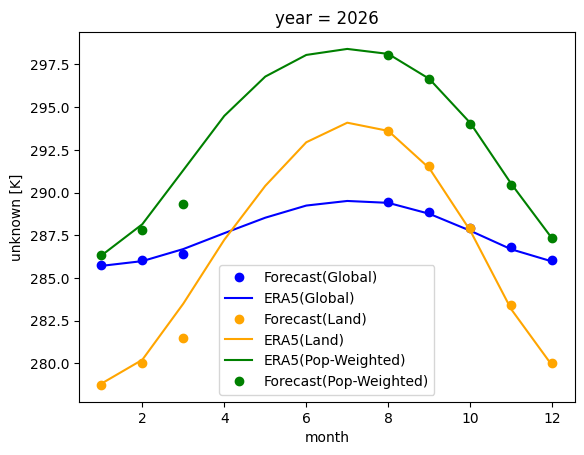

In [59]:
fc_global['tas'].plot(color = 'blue', label = 'Forecast(Global)', linestyle = '', marker = 'o')
era5_global['tas'].plot(color = 'blue', label = 'ERA5(Global)')

fc_land['tas'].plot(color = 'orange', label = 'Forecast(Land)', linestyle = '', marker = 'o')
era5_land['tas'].plot(color = 'orange', label = 'ERA5(Land)')

pop_weighted_anomaly_era5.plot(color = 'green', label = 'ERA5(Pop-Weighted)')
pop_weighted_anomaly_forecast.plot(color = 'green', label = 'Forecast(Pop-Weighted)', linestyle = '', marker = 'o')
plt.legend()

In [122]:
### Anomaly
# Analysis Period (1995-2027)
era5_analysis = era5_full.sel(time=slice("1995-01-01", "2026-07-31")).resample(time='MS').mean()
forecast_analysis = forecast.sel(time=slice("2026-08-01", "2027-02-28")).resample(time='MS').mean().compute()

# Subtract Monthly Climatology
era5_anomaly = era5_analysis.groupby('time.month') - era5_base
forecast_anomaly = forecast_analysis.groupby('time.month') - forecast_base

In [62]:
fc_global_anomaly = compute_area_weighted_mean(forecast_anomaly, lat_name="latitude", lon_name="longitude")
era5_global_anomaly = compute_area_weighted_mean(era5_anomaly, lat_name="latitude", lon_name="longitude")

fc_land_anomaly = compute_area_weighted_mean(analysis_utils.land_only(forecast_anomaly))
era5_land_anomaly = compute_area_weighted_mean(analysis_utils.land_only(era5_anomaly))

In [123]:
# Pop-Weighted
# Convert Ensemble Average to Impact Regions
era5_ir_anomaly = isku_utils.grid_to_ir(era5_anomaly['tas'])
forecast_ir_anomaly = isku_utils.grid_to_ir(forecast_anomaly['tas'])

merged_era5 = xr.merge([era5_ir_anomaly.rename('anomaly'), socioeconomics])
merged_forecast = xr.merge([forecast_ir_anomaly.rename('anomaly'), socioeconomics])

pop_weighted_anomaly_era5 = (merged_era5['anomaly'] * merged_era5['pop']).sum(dim='region') / merged_era5['pop'].sum(dim='region')
pop_weighted_anomaly_forecast = (merged_forecast['anomaly'] * merged_forecast['pop']).sum(dim='region') / merged_forecast['pop'].sum(dim='region')

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

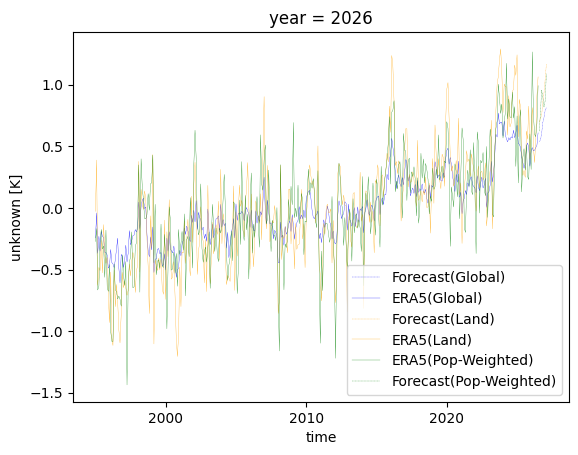

In [67]:
fc_global_anomaly['tas'].plot(color = 'blue', label = 'Forecast(Global)', linestyle = '--', linewidth = 0.2)
era5_global_anomaly['tas'].plot(color = 'blue', label = 'ERA5(Global)', linewidth = 0.2)

fc_land_anomaly['tas'].plot(color = 'orange', label = 'Forecast(Land)', linestyle = '--', linewidth = 0.2)
era5_land_anomaly['tas'].plot(color = 'orange', label = 'ERA5(Land)', linewidth = 0.2)

pop_weighted_anomaly_era5.plot(color = 'green', label = 'ERA5(Pop-Weighted)', linewidth = 0.2)
pop_weighted_anomaly_forecast.plot(color = 'green', label = 'Forecast(Pop-Weighted)', linestyle = '--', linewidth = 0.2)
plt.legend()

In [124]:
pop_weighted_anomaly_forecast.sel(time=slice("2026-08-01", "2027-01-31")).mean(dim = ['time', 'number']).values

array(0.82367161)

In [110]:
pop_weighted_anomaly_era5

<xarray.DataArray (time: 379)> Size: 3kB
dask.array<truediv, shape=(379,), dtype=float64, chunksize=(379,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 3kB 1995-01-01 00:00:00 ... 2026-07-01 00:00:00
    month    (time) int64 3kB dask.array<chunksize=(379,), meta=np.ndarray>
    number   int64 8B ...
    year     int64 8B 2026
Attributes:
    units:                  K
    poreallas_created_at:   2026-07-31T23:27:06.816984+00:00
    poreallas_uid:          3ef1dbad-c796-48b7-8b07-99616d3853d1
    poreallas_description:  Parsed ERA5 tas field

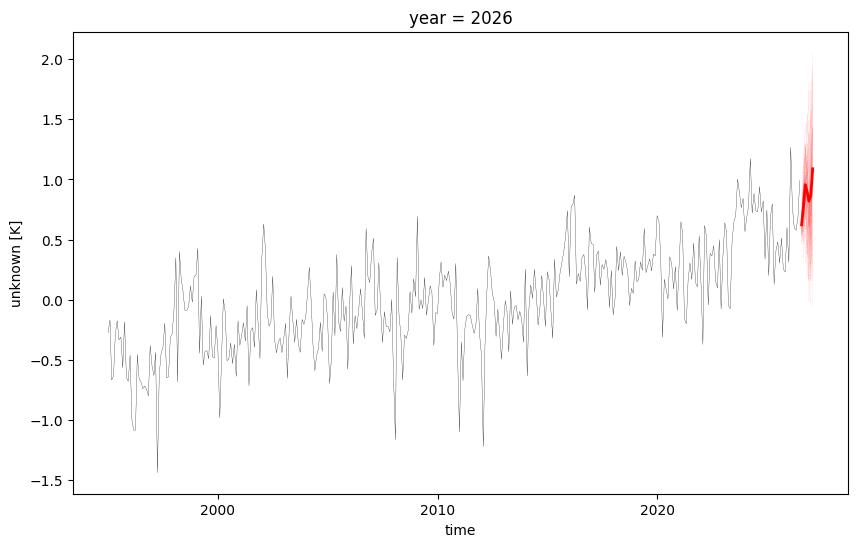

In [125]:
fig, ax = plt.subplots(figsize=(10, 6))
pop_weighted_anomaly_era5.plot(color = 'black', label = 'ERA5(Pop-Weighted)', linewidth = 0.2, ax = ax)

_ = pop_weighted_anomaly_forecast.plot.line(x = 'time', color = 'red', label = 'Forecast(Pop-Weighted)', linestyle = '--', alpha = 0.2, linewidth = 0.2, add_legend=False)
pop_weighted_anomaly_forecast.mean(dim = 'number').plot(color = 'red', label = 'Forecast', linewidth = 2, ax = ax)
#Rolling 12-month avg

In [76]:
pop_weighted_anomaly_era5 = pop_weighted_anomaly_era5.compute()
pop_weighted_anomaly_forecast = pop_weighted_anomaly_forecast.compute()

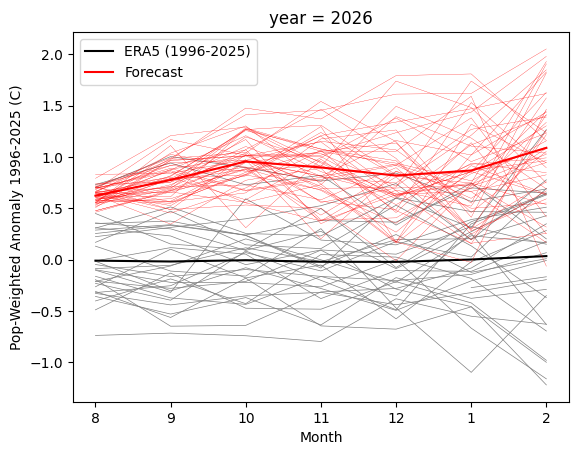

In [91]:
month_order = [8, 9, 10, 11, 12, 1, 2]
month_pos = {m: i for i, m in enumerate(month_order)}

fig, ax = plt.subplots()
month_arr = pop_weighted_anomaly_era5["time"].dt.month
year_arr = pop_weighted_anomaly_era5["time"].dt.year
season_year = xr.where(month_arr >= 8, year_arr, year_arr - 1)

ds_season = pop_weighted_anomaly_era5.assign_coords(season_year=("time", season_year.values))
ds_season = ds_season.sel(time=month_arr.isin(month_order))

for year, group in ds_season.groupby("season_year"):
    g = group.assign_coords(month_idx=("time", [month_pos[m] for m in group["time"].dt.month.values]))
    g.swap_dims({"time": "month_idx"}).plot(x="month_idx", color="gray", linewidth=0.5, ax=ax)
ds_season_mean = ds_season.groupby(ds_season["time"].dt.month).mean(dim="time")
ds_season_mean = ds_season_mean.rename(month="month_orig")
ds_season_mean = ds_season_mean.assign_coords(month_idx=("month_orig", [month_pos[m] for m in ds_season_mean["month_orig"].values]))
ds_season_mean.swap_dims({"month_orig": "month_idx"}).sortby("month_idx").plot(x="month_idx", color="black", linewidth=1.5, ax=ax, label='ERA5 (1996-2025)')

for i in range(51):
    member = pop_weighted_anomaly_forecast.isel(number=i)
    member = member.assign_coords(month=member["time"].dt.month)
    member = member.assign_coords(month_idx=("time", [month_pos[m] for m in member["month"].values]))
    member.swap_dims({"time": "month_idx"}).plot(x="month_idx", color="red", linewidth=0.2, ax=ax)
fc_mean = pop_weighted_anomaly_forecast.mean(dim = 'number')
fc_mean = fc_mean.assign_coords(month=fc_mean["time"].dt.month)
fc_mean = fc_mean.assign_coords(month_idx=("time", [month_pos[m] for m in fc_mean["month"].values]))
fc_mean = fc_mean.swap_dims({"time": "month_idx"})
fc_mean.plot(x="month_idx", color="red", linewidth=1.5, ax=ax, label = 'Forecast')
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order)
ax.set_xlabel("Month")
ax.set_ylabel("Pop-Weighted Anomaly 1996-2025 (C)")
ax.legend()

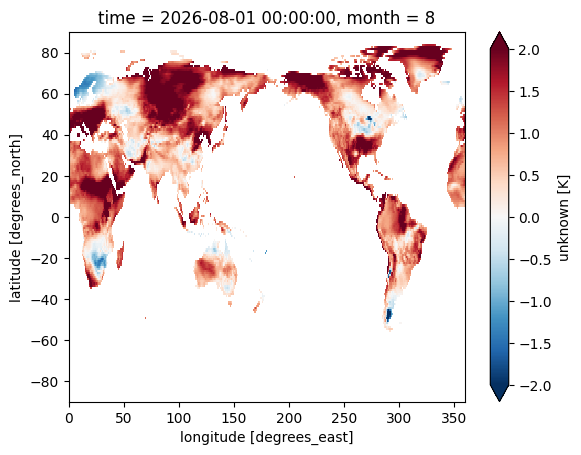

In [29]:
fc_land.sel(month = 8).mean(dim = 'number')['tas'].plot(vmin = -2, vmax = 2, cmap = 'RdBu_r')

In [35]:
fc_land_avg = compute_area_weighted_mean(fc_land)
fc_all_avg = compute_area_weighted_mean(forecast_anomaly, lat_name="latitude", lon_name="longitude")

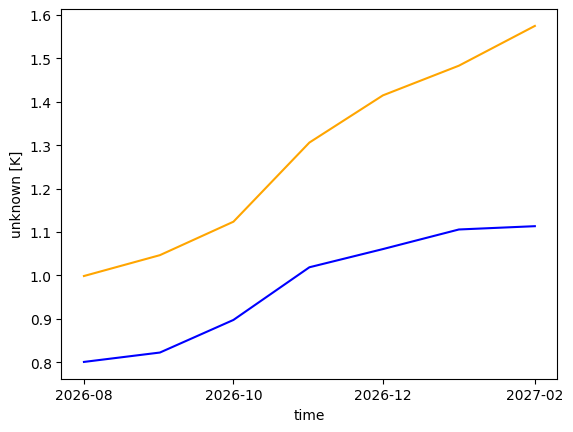

In [39]:
fc_land_avg.mean(dim = 'number')['tas'].plot(color = 'orange')
fc_all_avg.mean(dim = 'number')['tas'].plot(color = 'blue')

In [56]:
# Convert Ensemble Average to Impact Regions
anomaly_era5_ir = isku_utils.grid_to_ir(era5_anomaly['tas'], savefile="anomaly_era5_ir")
anomaly_forecast_ir = isku_utils.grid_to_ir(forecast_anomaly['tas'], savefile="anomaly_forecast_ir")


/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is

In [ ]:
merged_era5 = xr.merge([anomaly_era5_ir.rename('anomaly'), socioeconomics])
merged_forecast = xr.merge([anomaly_forecast_ir.rename('anomaly'), socioeconomics])

pop_weighted_anomaly_era5 = (merged_era5['anomaly'] * merged_era5['pop']).sum(dim='region') / merged_era5['pop'].sum(dim='region')
pop_weighted_anomaly_forecast = (merged_forecast['anomaly'] * merged_forecast['pop']).sum(dim='region') / merged_forecast['pop'].sum(dim='region')

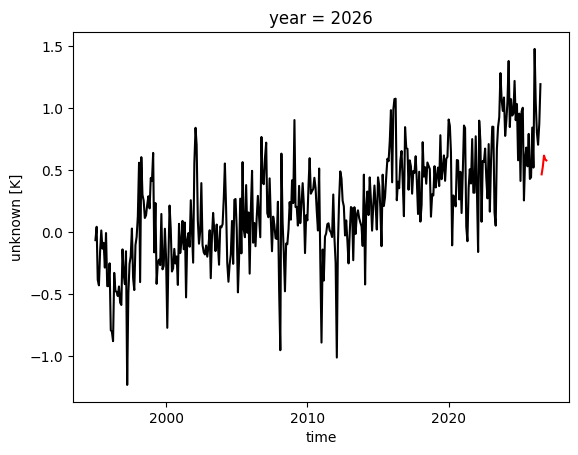

In [ ]:
pop_weighted_anomaly_era5.plot(color = 'k')
pop_weighted_anomaly_forecast.mean(dim='number').plot(color = 'r')